In [1]:
from datasets import load_dataset
from PIL import Image
import io
import base64
import matplotlib.pyplot as plt
import requests
from dotenv import load_dotenv
import os

def display_image(example):
    plt.figure(figsize=(12, 10))
    plt.imshow(example["image"])
    plt.title(example["slug"])
    plt.axis('off')
    plt.show()


dataset = load_dataset("Vokturz/sourceforge-app-screenshots")

/home/pudu/codegpt/codegpt-swe-bench/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 100%|███████████████████████████████████████████████████████████████████████████| 1393/1393 [00:00<00:00, 3512.51 examples/s]


In [2]:
def create_example(image_path: str, user_text: str, assistant_text: str):
    with open(image_path, "rb") as f:
        image_bytes = f.read()
        image_base64 = base64.b64encode(image_bytes).decode("utf-8")

    user_message =  {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": user_text
            },
            {
                "type": "image_url",
                "image_url": {  
                    "url": f"data:image/png;base64,{image_base64}"
                }
            }
        ]
    }

    assistant_message = {
        "role": "assistant",
        "content": [
            {
                "type": "text",
                "text": assistant_text
            }
        ]
    }

    return [user_message, assistant_message]

In [18]:
SYSTEM_PROMPT = """You are Loyca.ai, an AI assistant that analyzes computer screenshots to describe what is currently visible on screen.

Your goal is to provide an objective description of the current window content, focusing on:
- What is currently displayed in the screenshot
- The specific content, files, or information visible
- Observable elements without inferring user intentions or goals

For each screenshot, describe only what you can directly observe. Do not make assumptions about what the user is trying to accomplish or their intentions. Each screenshot is independent and should be described separately.

For classification, choose the MOST APPROPRIATE category from these options:
- code editor: Writing code, IDE usage
- terminal: Command line, shell operations
- document editor: Word processing, writing documents
- spreadsheets: Excel, Google Sheets, data tables
- database tools: SQL editors, database management (actual tools, not reading about databases)
- email app: Email clients, composing/reading emails
- chat/messaging: Slack, Discord, instant messaging
- video conferencing: Zoom, Teams, video calls
- file manager: File explorers, directory browsing
- music streaming: Spotify, Apple Music, audio streaming
- video streaming: YouTube, Netflix, video content
- social media: Twitter, Facebook, Instagram, LinkedIn, Reddit
- online shopping: E-commerce, shopping websites
- research/browsing: Web browsing, reading articles, StackOverflow, documentation
- game: Gaming applications
- other: Anything that doesn't fit the above categories

Your answer must use <description> tags for the description, <keywords> tags for keywords, and <category> tags for classification."""

example_1 = [
    "../data/examples/code-editor.png",
    "This application whose process name is \"dev.zed.Zed\" has the following title: \"loyca-ai - sql.rs\"",
    """<description>
A Rust file, `sql.rs`, is open in the "loyca-ai" Tauri project. The code implements a thread-safe, lazily-initialized singleton pattern for a SQLite database connection using the `once_cell` and `Mutex` crates. The `init` function retrieves the application's data directory via the Tauri API to create or open an `sqlite.db` file with `rusqlite`.
</description>
<keywords>Rust, Tauri, SQLite, rusqlite, database connection, singleton pattern, thread safety, OnceCell, backend development</keywords>
<category>code editor</category>"""
]
example_2 = [
    "../data/examples/reddit.png",
    "This application whose process name is \"app.zen_browser.zen\" has the following title: \"Reddit - The heart of the internet — Zen Browser\".",
    """"<description>
The user is browsing their Reddit feed. Two posts are visible: one from the subreddit r/PeterExplainsTheJoke titled "What game??", showing an image of a Chuck E. Cheese building with smoke coming from it and the caption "Somebody beat the game". Below it is a post from r/LocalLLaMA titled "Local reasoning model", asking for recommendations for non-Chinese AI reasoning models.
</description>
<keywords>Reddit, social media, meme, r/PeterExplainsTheJoke, r/LocalLLaMA, AI models, LLM, reasoning model, browsing</keywords>
<category>social media</category>"""
]

FEW_SHOT_EXAMPLES = create_example(*example_1) + create_example(*example_2)

In [27]:
base_url = os.environ['BASE_URL']
model = os.environ['MODEL']

In [28]:
def do_image_analysis(
    example,
    base_url="http://localhost:8000",
    model="qwen/qwen3-coder-30b",
    print_assistant_message=False,
    temperature=0.7,
    stream=False,
    api_key="no-key",
):
    url = f"{base_url}/v1/chat/completions"

    headers = {"Content-Type": "application/json", "Authorization": f"Bearer {api_key}"}

    user_text = f'This application whose process name is "{example["slug"]}" has the following title: "{example["title"]}".'
    # if len(example['topics']) > 0:
    #     user_text += ' This are the sourceforge topics of that app: ' + ', '.join(example['topics']) + '.'
    # if example['description']:
    #     user_text += f'And this is the app description:\n{example["description"].split("\n")[0]}\n'

    user_text += ' Describe only what you can see in this screenshot without making assumptions about user intentions or goals. Don\'t forget to use <description>, <keywords>, and <category> tags separately.'

    print(user_text)

    img = example["image"]
    buffer = io.BytesIO()
    img.save(buffer, format="PNG")
    buffer.seek(0)
    image_base64 = base64.b64encode(buffer.read()).decode("utf-8")

    
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        *FEW_SHOT_EXAMPLES,
        {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": user_text
            },
            {
                "type": "image_url",
                "image_url": {  
                    "url": f"data:image/png;base64,{image_base64}"
                }
            }
        ]
    },
    ]

    data = {
        "model": model,
        "messages": messages,
        "temperature": temperature,
        "stream": stream,
    }

    response = requests.post(url, headers=headers, json=data)
    response.raise_for_status()

    resp = response.json()
    assistant_message = resp["choices"][0]["message"]["content"]

    if print_assistant_message:
        print(assistant_message)

    # file_path = next(
    #     re.finditer(r"<file_path>(.*?)</file_path>", assistant_message, re.DOTALL)
    # ).group(1)

    # return file_path.strip()


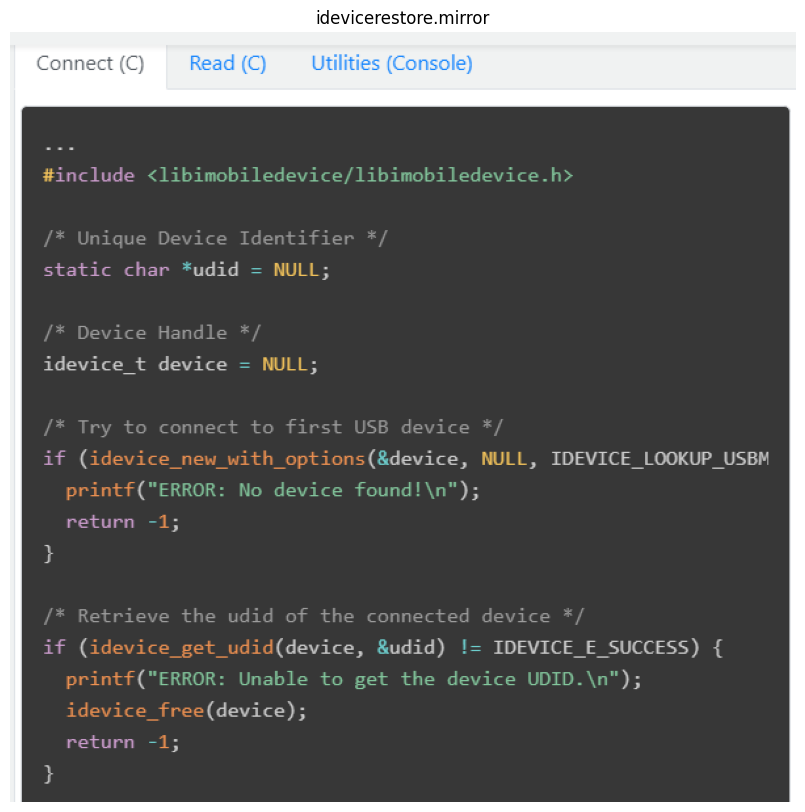

{'slug': 'idevicerestore.mirror',
 'url': 'https://sourceforge.net/projects/idevicerestore.mirror/',
 'title': 'idevicerestore',
 'registration_date': datetime.datetime(2023, 7, 4, 0, 0),
 'description': 'A command-line application to restore firmware files to iOS devices. The iDevice restore application is a full reimplementation of all granular steps which are performed during the restore of firmware to a device. In general, upgrades and downgrades are possible, however subject to the availability of SHSH blobs from Apple for signing the firmware files. idevicerestore requires a properly installed usbmuxd for the restore procedure. Please make sure that it is either running or configured to be started automatically as soon as a device is detected in normal and/or restore mode. If properly installed this will be handled by udev/systemd.',
 'is_mirror': True,
 'topics': ['frameworks'],
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=599x587>,
 'width': 599,
 'height': 58

In [29]:
example = dataset['train'][390]
display_image(example)
example

In [30]:
do_image_analysis(example, base_url, model, True)

This application whose process name is "idevicerestore.mirror" has the following title: "idevicerestore". Describe only what you can see in this screenshot without making assumptions about user intentions or goals. Don't forget to use <description>, <keywords>, and <category> tags separately.
<description>
The screenshot shows a code editor with a C file open, likely a part of a program for interacting with iOS devices. The code includes a function that attempts to connect to a USB device using the `idevice_new_with_options` function. It also contains a function to retrieve the unique device identifier (UDID) of a connected device. The code is part of a project that uses the libimobiledevice library, as indicated by the include statement. The error messages in the code suggest that the program is designed to handle cases where no device is found or the UDID cannot be retrieved.
</description>
<keywords>idevicerestore, C code, libimobiledevice, iOS, device connection, USB, UDID, error h

In [4]:
def check_screenshot_validity(
    example,
    base_url="http://localhost:8000",
    model="qwen/qwen3-coder-30b",
    print_assistant_message=False,
    temperature=0.,
    stream=False,
    api_key="no-key",
):
    url = f"{base_url}/v1/chat/completions"

    headers = {"Content-Type": "application/json", "Authorization": f"Bearer {api_key}"}

    user_text = f'Is this image from the application "{example["title"]}" valid?.'
    # if len(example['topics']) > 0:
    #     user_text += ' This are the sourceforge topics of that app: ' + ', '.join(example['topics']) + '.'
    if example['description']:
        user_text += f'This is the description from sourceforge:\n{example["description"].split("\n")[0]}\n'

    print(user_text)

    img = example["image"]
    buffer = io.BytesIO()
    img.save(buffer, format="PNG")
    buffer.seek(0)
    image_base64 = base64.b64encode(buffer.read()).decode("utf-8")


    SYSTEM_PROMPT = """You are Loyca.ai, an AI assistant that analyzes computer screenshots to determine if they truly belong to a given software application.

Your goal is to judge whether the screenshot shows the actual interface of the application or if it is unrelated content (like documentation, OS dialogs, other apps, or collages).

---

### VALID SCREENSHOTS
A screenshot is VALID if it shows:
- The main user interface of the application (windows, menus, toolbars, dashboards, dialogs, or panels).
- Dialogs or configuration windows belonging to the application itself.
- Remote or cross-platform features correctly displayed inside the application (e.g., Unix file permissions in WinSCP, ISO selection menus in Ventoy).
- A single screen or window of the app.  

### INVALID SCREENSHOTS
A screenshot is INVALID if it shows:
- Other applications, OS dialogs, or system windows unrelated to the target app.
- Multiple images, collages, or documentation screenshots (including markdown tables or diagrams).
- Marketing banners, splash screens, logos, or icons not part of the active interface.
- Screenshots too small or unreadable to identify as belonging to the application.
- Mobile interface (Android, APK related apps, Iphone).

---

### ADDITIONAL GUIDELINES
- Do not assume that Unix-like UI elements, permissions, or OS-specific terms automatically make the screenshot invalid.
- Use the app title and description as context, but rely primarily on what is visible in the screenshot.
- Provide concise reasoning for your judgment.
- ONLY COMPUTER APPS ARE VALID. Any mobile app is invalid.
- Use plain English, responding in the following format:

VALID: [brief reason]  
INVALID: [brief reason]

Be precise, clear, and consistent."""

    
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        # *FEW_SHOT_EXAMPLES,
        {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": user_text
            },
            {
                "type": "image_url",
                "image_url": {  
                    "url": f"data:image/png;base64,{image_base64}"
                }
            }
        ]
    },
    ]

    data = {
        "model": model,
        "messages": messages,
        "temperature": temperature,
        "stream": stream,
    }

    response = requests.post(url, headers=headers, json=data)
    response.raise_for_status()

    resp = response.json()
    assistant_message = resp["choices"][0]["message"]["content"]

    if print_assistant_message:
        print(assistant_message)

    # file_path = next(
    #     re.finditer(r"<file_path>(.*?)</file_path>", assistant_message, re.DOTALL)
    # ).group(1)

    # return file_path.strip()


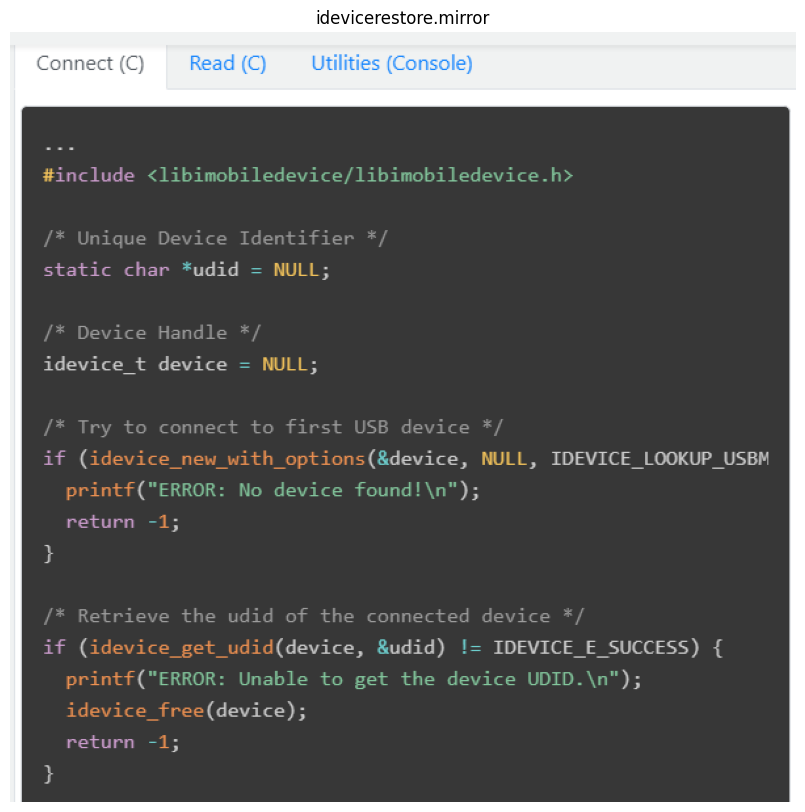

{'slug': 'idevicerestore.mirror',
 'url': 'https://sourceforge.net/projects/idevicerestore.mirror/',
 'title': 'idevicerestore',
 'registration_date': datetime.datetime(2023, 7, 4, 0, 0),
 'description': 'A command-line application to restore firmware files to iOS devices. The iDevice restore application is a full reimplementation of all granular steps which are performed during the restore of firmware to a device. In general, upgrades and downgrades are possible, however subject to the availability of SHSH blobs from Apple for signing the firmware files. idevicerestore requires a properly installed usbmuxd for the restore procedure. Please make sure that it is either running or configured to be started automatically as soon as a device is detected in normal and/or restore mode. If properly installed this will be handled by udev/systemd.',
 'is_mirror': True,
 'topics': ['frameworks'],
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=599x587>,
 'width': 599,
 'height': 58

In [16]:
example = dataset['train'][390]
display_image(example)
example

In [10]:
check_screenshot_validity(example, base_url, model, True)

Is this image from the application "GAUDIKA Legacy" valid?.This is the description from sourceforge:
Reproductor de Audio portable basado en la librería BASS, Liviano, Rápido y simple de usar.  Ahora soporta multiples lenguajes. 

VALID: The screenshot displays the interface of the GAUDIKA Legacy application, including its main window with a music player, a list of tracks, and an "About" dialog box showing version information, compilation date, and supported features. The title bar confirms the application name, and the content matches the described functionality as a portable audio player based on the BASS library. All elements are consistent with the software's purpose and branding.


In [22]:
def ocr(
    example,
    base_url="http://localhost:8000",
    model="qwen/qwen3-coder-30b",
    print_assistant_message=False,
    temperature=0.,
    stream=False,
    api_key="no-key",
):
    url = f"{base_url}/v1/chat/completions"

    headers = {"Content-Type": "application/json", "Authorization": f"Bearer {api_key}"}

    user_text = f'Do OCR for "{example["title"]}". '
    # if len(example['topics']) > 0:
    #     user_text += ' This are the sourceforge topics of that app: ' + ', '.join(example['topics']) + '.'

    user_text = 'The screenshot shows a code editor with a C file open, likely a part of a program for interacting with iOS devices. The code includes a function that attempts to connect to a USB device using the `idevice_new_with_options` function. It also contains a function to retrieve the unique device identifier (UDID) of a connected device. The code is part of a project that uses the libimobiledevice library, as indicated by the include statement. The error messages in the code suggest that the program is designed to handle cases where no device is found or the UDID cannot be retrieved.'
    print(user_text)

    img = example["image"]
    buffer = io.BytesIO()
    img.save(buffer, format="PNG")
    buffer.seek(0)
    image_base64 = base64.b64encode(buffer.read()).decode("utf-8")


    SYSTEM_PROMPT = """You are Loyca.ai, an AI assistant that performs OCR (optical character recognition) on application screenshots.
Your goal is to extract all meaningful text from the screenshot and output it in **Markdown format**.

---

### WHAT TO EXTRACT
Include all **relevant textual content** that helps represent what the user sees in the application:
- Main content areas (documents, code editors, output panels, logs, etc.).
- Dialogs, modals, alerts, pop-ups, or configuration windows that are part of the app.
- Labels, messages, or error text inside the app.
- File contents, command output, or structured text shown in the main window.

---

### WHAT TO IGNORE
Exclude visual elements that do not add meaningful text content:
- Operating system window borders, title bars, or toolbar button labels like “File”, “Edit”, “Help”.
- Generic UI chrome (e.g., minimize/maximize buttons, scrollbar text).
- Repetitive or irrelevant sidebar items unrelated to the visible main content.
- Text that is partially unreadable or cut off — do not guess or invent it.

---

### OUTPUT RULES
1. **Format** the extracted text as valid **Markdown**:
   - Use `#`, `##`, etc. for headings.
   - Preserve bullet points, numbered lists, and indentation.
   - Use backticks for code (`inline`) or triple backticks for code blocks.
   - Use tables (`| A | B |`) if the text is tabular.

2. **No commentary or extra text**:
   - Do not describe the image.
   - Only output the extracted text in Markdown — nothing else.

3. **Faithfulness**:
   - Keep the original wording, punctuation, and structure.
   - If something looks like code, render it as a fenced code block.

---
"""

    
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        # *FEW_SHOT_EXAMPLES,
        {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": user_text
            },
            {
                "type": "image_url",
                "image_url": {  
                    "url": f"data:image/png;base64,{image_base64}"
                }
            }
        ]
    },
    ]

    data = {
        "model": model,
        "messages": messages,
        "temperature": temperature,
        "stream": stream,
    }

    response = requests.post(url, headers=headers, json=data)
    response.raise_for_status()

    resp = response.json()
    assistant_message = resp["choices"][0]["message"]["content"]

    if print_assistant_message:
        print(assistant_message)

    # file_path = next(
    #     re.finditer(r"<file_path>(.*?)</file_path>", assistant_message, re.DOTALL)
    # ).group(1)

    # return file_path.strip()


In [183]:
def filter_by_topics(example, topics):
    return any(topic in example['topics'] for topic in topics)


data = dataset.filter(lambda x: filter_by_topics(x, ['software-development']))
data

Filter:   0%|          | 0/1046 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['slug', 'url', 'title', 'registration_date', 'description', 'is_mirror', 'topics', 'image', 'width', 'height'],
        num_rows: 51
    })
})

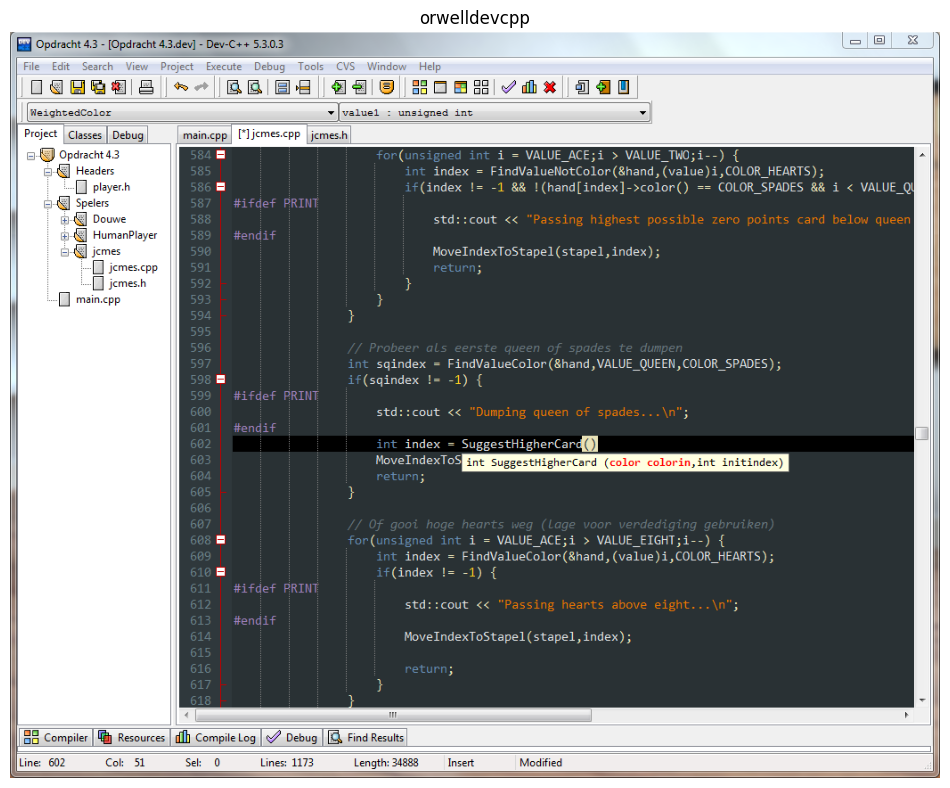

{'slug': 'orwelldevcpp',
 'url': 'https://sourceforge.net/p/orwelldevcpp/',
 'title': 'Dev-C++',
 'registration_date': datetime.datetime(2011, 10, 15, 0, 0),
 'description': 'A new and improved fork of Bloodshed Dev-C++ ',
 'is_mirror': False,
 'topics': ['integrated-development-environments-ide',
  'software-development',
  'code-editors',
  'code-formatters'],
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1044x838>,
 'width': 1044,
 'height': 838}

In [219]:
example = data['train'][0]
display_image(example)
example

In [23]:
ocr(example, base_url, model, True)

The screenshot shows a code editor with a C file open, likely a part of a program for interacting with iOS devices. The code includes a function that attempts to connect to a USB device using the `idevice_new_with_options` function. It also contains a function to retrieve the unique device identifier (UDID) of a connected device. The code is part of a project that uses the libimobiledevice library, as indicated by the include statement. The error messages in the code suggest that the program is designed to handle cases where no device is found or the UDID cannot be retrieved.
```c
#include <libimobiledevice/libimobiledevice.h>

/* Unique Device Identifier */
static char *udid = NULL;

/* Device Handle */
idevice_t device = NULL;

/* Try to connect to first USB device */
if (idevice_new_with_options(&device, NULL, IDEVICE_LOOKUP_USB) != IDEVICE_E_SUCCESS) {
    printf("ERROR: No device found!\n");
    return -1;
}

/* Retrieve the udid of the connected device */
if (idevice_get_udid(dev